<a href="https://colab.research.google.com/github/humairaneha/Learning-Pytorch/blob/main/Hyperparameter_Tuning_Using_Optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


In [22]:
#set random seeds for reproducibilty
torch.manual_seed(42)


In [23]:
# check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device} ')

using device: cuda 


In [24]:
df_train = pd.read_csv('fashion-mnist_train.csv')

df_test = pd.read_csv('fashion-mnist_test.csv')
df_train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
X_train = df_train.iloc[:,1:].values #convert to numpy array
y_train = df_train.iloc[:,0].values
X_test = df_test.iloc[:,1:].values
y_test = df_test.iloc[:,0].values

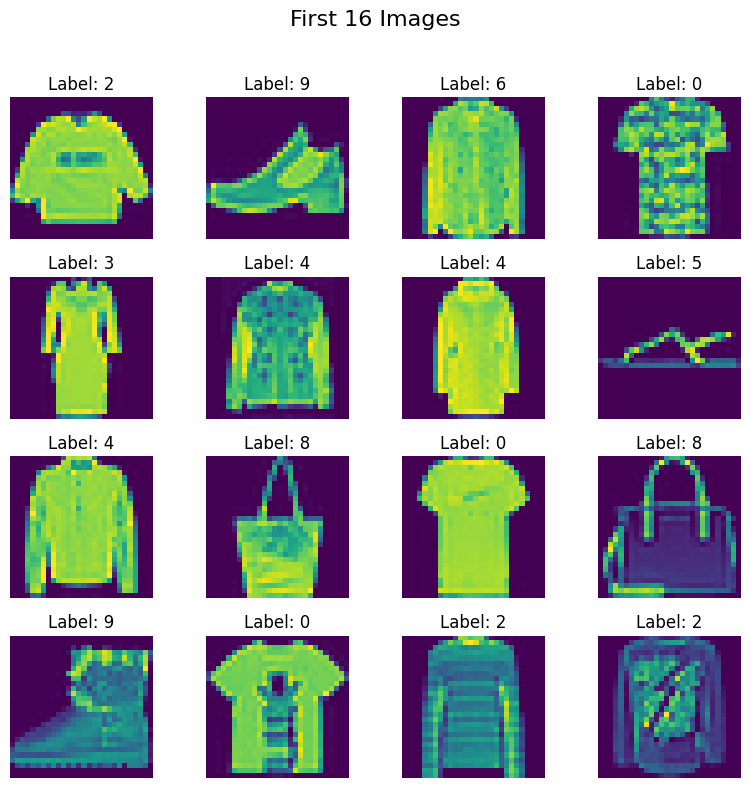

In [26]:
#plotting first 16 images from dataset on a 4*4 grid

fig, axes = plt.subplots(4,4, figsize=(8,8))
fig.suptitle("First 16 Images", fontsize=16)
for i, ax in enumerate(axes.flat):
    img = df_train.iloc[i,1:].values.reshape(28,28) #reshape to 28*28
    ax.imshow(img) #Display in grayscale
    ax.axis('off') #Remove axis for a cleaner look
    ax.set_title(f"Label: {df_train.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


#train test split

In [27]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((60000, 784), (10000, 784), (60000,), (10000,))

#scaling the features

In [28]:
X_train = X_train/255.0
X_test = X_test/255.0

#creating custom dataset class


In [29]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features , dtype=torch.float32)
    self.labels = torch.tensor(labels , dtype= torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index], self.labels[index]



In [30]:
# create train and test dataset object

train_dataset = CustomDataset(X_train, y_train)

test_dataset = CustomDataset(X_test, y_test)



# creating train and test dataloader

#Optimize the GPU Usage


1.   Use larger batch size to reduce computation per epoch
2.   Enable DataLoader Pinning to speed up data transfer from CPU to GPU : Use **pin_memory = True**









#Optuna Objective Function

#creating model
Model structure

input layer

hidden layer 1 : 128 neurons

hidden layer 2: 64 neuorns

output layer

In [31]:
from torch.nn.modules.activation import Softmax
#define nn class



class Model_ANN(nn.Module):
  def __init__(self, input_dim,output_dim , num_hidden_layers , neurons_per_layer,dropout_rate):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim, neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(p=dropout_rate))
      input_dim = neurons_per_layer

    #output layer
    layers.append(nn.Linear(neurons_per_layer, output_dim))
    self.model = nn.Sequential (*layers) #unpacking the layers from the list

  def forward(self,X):
    return self.model(X)




In [32]:
!pip install mlflow

In [36]:
  #objective function
def objective(trial):

    #next hyperparameter values from the search space

    num_hidden_layers = trial.suggest_int("num_hidden_layers", 3, 6)
    neurons_per_layer = trial.suggest_int("neurons_per_layer", 32 ,128, step = 8 )
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    epochs = trial.suggest_int("epochs", 10, 50,step=10)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5,step=0.1)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ['Adam', 'SGD', 'RMSprop'])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)


    with mlflow.start_run(nested=True):
      mlflow.log_param("num_hidden_layers", num_hidden_layers)
      mlflow.log_param("neurons_per_layer", neurons_per_layer)
      mlflow.log_param("learning_rate", learning_rate)
      mlflow.log_param("epochs", epochs)
      mlflow.log_param("dropout_rate", dropout_rate)
      mlflow.log_param("batch_size", batch_size)
      mlflow.log_param("optimizer", optimizer_name)
      mlflow.log_param("weight_decay", weight_decay)


      #model init

      train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
      test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,pin_memory=True)

      input_dim = 784
      output_dim = 10
      my_model = Model_ANN(input_dim, output_dim, num_hidden_layers, neurons_per_layer,dropout_rate)
      my_model = my_model.to(device)

      #loss function

      criterion  = nn.CrossEntropyLoss()

      #params init

      #optimizer selection

      #optimizer = optim.SGD(my_model.parameters(), lr=learning_rate)
      if optimizer_name=='Adam':
        optimizer = optim.Adam(my_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      elif optimizer_name=='SGD':
        optimizer = optim.SGD(my_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      else:
        optimizer = optim.RMSprop(my_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      #training loop

      for epoch in range(epochs):

        total_epoch_loss = 0

        for batch_features, batch_targets in train_dataloader:

            #Move data to gpu

            batch_features = batch_features.to(device)
            batch_targets = batch_targets.to(device)


            #forward pass
            outputs = my_model(batch_features)

            #calculate loss
            loss = criterion(outputs, batch_targets)


            #backward pass
            optimizer.zero_grad()
            loss.backward()
            #update parameters
            optimizer.step()
            total_epoch_loss = total_epoch_loss + loss.item()

        avg_loss = total_epoch_loss/len(train_dataloader) # avg loss per epoch : no of batches

        print(f'Epoch: {epoch+1}, Loss: {avg_loss}')


      #evaluation

      #set model to eval mode

      my_model.eval()
      #evaluation

      total = 0
      correct = 0

      with torch.no_grad():

        for test_features, test_targets in test_dataloader:

        #Move data to gpu

          test_features = test_features.to(device)
          test_targets = test_targets.to(device)

          outputs =  my_model(test_features)

          #  prob = torch.softmax(outputs,dim=1)


          #  prediction = torch.argmax(prob,dim=1)
          _ ,prediction = torch.max(outputs,dim=1)

          total = total+ test_targets.shape[0]

          correct= correct + (prediction==test_targets).sum().float().item()

      accuracy = correct/total

      mlflow.log_metric("accuracy", accuracy)


      return accuracy

In [34]:
!pip install optuna
!pip install mlflow

In [ ]:
import optuna
import mlflow
mlflow.set_experiment("pytorch_optuna_experiment")

with mlflow.start_run(run_name="optuna_tuning"):
  mlflow.log_param("framework", "pytorch")

  study = optuna.create_study(direction='maximize') # since we are working with accuracy, if we consider loss then we've to use minimizw
  study.optimize(objective, n_trials=50)
  mlflow.log_params(study.best_params)
  mlflow.log_metric("best_val_accuracy", study.best_value)


[I 2026-06-29 15:21:02,652] A new study created in memory with name: no-name-b3d23b46-fab4-432b-ae37-0e69475fb773


Epoch: 1, Loss: 1.3473954495590632
Epoch: 2, Loss: 0.8465503665175773
Epoch: 3, Loss: 0.7303895874064106
Epoch: 4, Loss: 0.669094154067131
Epoch: 5, Loss: 0.6250993626585393
Epoch: 6, Loss: 0.6027968159235363
Epoch: 7, Loss: 0.5821875251178295
Epoch: 8, Loss: 0.5669120050696675
Epoch: 9, Loss: 0.5449736590451523


[I 2026-06-29 15:21:29,370] Trial 0 finished with value: 0.8632 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 112, 'learning_rate': 0.00018007696085741898, 'epochs': 10, 'dropout_rate': 0.5, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 0.00040395228841743307}. Best is trial 0 with value: 0.8632.


Epoch: 10, Loss: 0.5413024024541444
Epoch: 1, Loss: 2.1881613282521566
Epoch: 2, Loss: 1.971072703933716
Epoch: 3, Loss: 1.8632465208053588
Epoch: 4, Loss: 1.7808309319178264
Epoch: 5, Loss: 1.7139660899480185
Epoch: 6, Loss: 1.6537078597386679
Epoch: 7, Loss: 1.6026125907262165
Epoch: 8, Loss: 1.555314924430847
Epoch: 9, Loss: 1.510558286412557
Epoch: 10, Loss: 1.4720734182357789
Epoch: 11, Loss: 1.432098548634847
Epoch: 12, Loss: 1.3999319976806641
Epoch: 13, Loss: 1.3660325417200725
Epoch: 14, Loss: 1.3397090951919555
Epoch: 15, Loss: 1.3098946624120076
Epoch: 16, Loss: 1.2809490664800007
Epoch: 17, Loss: 1.254341193453471
Epoch: 18, Loss: 1.230639476108551
Epoch: 19, Loss: 1.206382682387034
Epoch: 20, Loss: 1.1847812780698141


[I 2026-06-29 15:23:26,070] Trial 1 finished with value: 0.749 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 48, 'learning_rate': 4.6056099006304925e-05, 'epochs': 20, 'dropout_rate': 0.1, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0009379270359420324}. Best is trial 0 with value: 0.8632.


...

Epoch: 1, Loss: 0.761663784122467
Epoch: 2, Loss: 0.5207826601386071
Epoch: 3, Loss: 0.4682429591377576
Epoch: 4, Loss: 0.4368031567364931
Epoch: 5, Loss: 0.4157709621806939
Epoch: 6, Loss: 0.4029174927324057
Epoch: 7, Loss: 0.38959446528057257
Epoch: 8, Loss: 0.3811908119092385
Epoch: 9, Loss: 0.37323072112252315
Epoch: 10, Loss: 0.3630079812159141
Epoch: 11, Loss: 0.35549686464915675
Epoch: 12, Loss: 0.3490897963364919
Epoch: 13, Loss: 0.3458854802687963
Epoch: 14, Loss: 0.34057112017671265
Epoch: 15, Loss: 0.3361761472463608
Epoch: 16, Loss: 0.3309156111031771
Epoch: 17, Loss: 0.33047373456855617
Epoch: 18, Loss: 0.32626677020837863
Epoch: 19, Loss: 0.3222389277994633
Epoch: 20, Loss: 0.32013238535771765
Epoch: 21, Loss: 0.31615968498140573
Epoch: 22, Loss: 0.31131842896838985
Epoch: 23, Loss: 0.3073467147663236
Epoch: 24, Loss: 0.3030736028894782
Epoch: 25, Loss: 0.3057793888012568
Epoch: 26, Loss: 0.30179898070345323
Epoch: 27, Loss: 0.29747454782128335
Epoch: 28, Loss: 0.29964228

[I 2026-06-29 17:11:07,862] Trial 22 finished with value: 0.8983 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 96, 'learning_rate': 0.00013037993746039855, 'epochs': 50, 'dropout_rate': 0.1, 'batch_size': 16, 'optimizer': 'Adam', 'weight_decay': 0.0006673410223329314}. Best is trial 21 with value: 0.9027.


Epoch: 1, Loss: 0.6464029411097367
Epoch: 2, Loss: 0.5094449676175912
Epoch: 3, Loss: 0.4802259674668312
Epoch: 4, Loss: 0.46276500197052955
Epoch: 5, Loss: 0.45184795922239623
Epoch: 6, Loss: 0.44542860399484635
Epoch: 7, Loss: 0.44357435040275256
Epoch: 8, Loss: 0.4352098163624605
Epoch: 9, Loss: 0.43593612782259783
Epoch: 10, Loss: 0.432053557352225
Epoch: 11, Loss: 0.42808572299083075
Epoch: 12, Loss: 0.42588919402460257
Epoch: 13, Loss: 0.4255971265455087
Epoch: 14, Loss: 0.4227554734448592
Epoch: 15, Loss: 0.4212455456475417
Epoch: 16, Loss: 0.4254813386003176
Epoch: 17, Loss: 0.4231687150547902
Epoch: 18, Loss: 0.4228493935485681
Epoch: 19, Loss: 0.42430220034917193
Epoch: 20, Loss: 0.4195554180790981
Epoch: 21, Loss: 0.4147635094732046
Epoch: 22, Loss: 0.41721830551922323
Epoch: 23, Loss: 0.420058045989275
Epoch: 24, Loss: 0.41790964492559435
Epoch: 25, Loss: 0.41863541849950947
Epoch: 26, Loss: 0.41920178532103697
Epoch: 27, Loss: 0.41833126821716626
Epoch: 28, Loss: 0.4166739

[I 2026-06-29 17:22:09,169] Trial 23 finished with value: 0.876 and parameters: {'num_hidden_layers': 4, 'neurons_per_layer': 88, 'learning_rate': 0.0006613429742499281, 'epochs': 50, 'dropout_rate': 0.1, 'batch_size': 16, 'optimizer': 'Adam', 'weight_decay': 0.0009804910295188646}. Best is trial 21 with value: 0.9027.


Epoch: 1, Loss: 1.0986639696995417
Epoch: 2, Loss: 0.6414120074868203
Epoch: 3, Loss: 0.5433968398034572
Epoch: 4, Loss: 0.5013693748176098
Epoch: 5, Loss: 0.4693604198724031
Epoch: 6, Loss: 0.4508692066907883
Epoch: 7, Loss: 0.4343268313070138
Epoch: 8, Loss: 0.42211362871030966
Epoch: 9, Loss: 0.409661992046237
Epoch: 10, Loss: 0.40040613379379114
Epoch: 11, Loss: 0.3917566080590089
Epoch: 12, Loss: 0.38667457960148655
Epoch: 13, Loss: 0.37798963696261245
Epoch: 14, Loss: 0.37111054071585337
Epoch: 15, Loss: 0.36717100118398666
Epoch: 16, Loss: 0.359521153485775
Epoch: 17, Loss: 0.35211412434776623
Epoch: 18, Loss: 0.34895383628408116
Epoch: 19, Loss: 0.347355626172324
Epoch: 20, Loss: 0.3408305835574865
Epoch: 21, Loss: 0.33485906016379596
Epoch: 22, Loss: 0.33439268004844586
Epoch: 23, Loss: 0.3303650307148695
Epoch: 24, Loss: 0.3279297655984759
Epoch: 25, Loss: 0.3262036935508251
Epoch: 26, Loss: 0.32154722577879824
Epoch: 27, Loss: 0.3165851334979137
Epoch: 28, Loss: 0.3130513327